In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

OVERVIEW OF WHOLE PROJECT

In [2]:
# airbnb-price-prediction/
# ├── venv/                          (your virtual environment — already made)
# ├── data/
# │   ├── raw/                       (original downloaded CSV, untouched)
# │   └── processed/                 (cleaned data you'll save after cleaning steps)
# ├── notebooks/
# │   ├── 01_data_exploration.ipynb  (first look: shape, columns, missing values)
# │   ├── 02_data_cleaning.ipynb     (handle missing prices, outliers, messy fields)
# │   ├── 03_feature_engineering.ipynb (distance-to-center, host buckets, etc.)
# │   ├── 04_eda_visualization.ipynb (charts, the host-analysis narrative)
# │   ├── 05_modeling.ipynb          (baseline → RF/XGBoost → evaluation)
# │   └── 06_shap_explainability.ipynb (what drives price)
# ├── app/
# │   └── app.py                     (Streamlit app, built later)
# ├── requirements.txt               (list of installed packages, for GitHub)
# ├── README.md                      (project explanation, for GitHub)
# └── .gitignore                     (tells git to ignore venv/, data/raw/, etc.)

In [3]:
# loading the dataset

df = pd.read_csv('../data/raw/listings_csv.csv')

In [4]:
# head

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,28871,https://www.airbnb.com/rooms/28871,20260615212022,2026-06-16,previous scrape,Comfortable double room,Basic bedroom in the center of Amsterdam.,NaN,https://a0.muscache.com/pictures/160889/362340...,124245,...,4.94,4.93,4.83,0363 607B EA74 0BD8 2F6F,NaN,2,0,2,0,4.15
1,29051,https://www.airbnb.com/rooms/29051,20260615212022,2026-06-16,previous scrape,Comfortable single / double room,This room can also be rented as a single or a ...,NaN,https://a0.muscache.com/pictures/162009/bd6be2...,124245,...,4.93,4.88,4.79,0363 607B EA74 0BD8 2F6F,NaN,2,0,2,0,4.88
2,44129,https://www.airbnb.com/rooms/44129,20260615212022,2026-06-24,previous scrape,Luxury design with canal view,"Welcome to my little gem<br /><br />Cozy, brig...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,187728,...,4.89,4.95,4.59,03635399E87602900F47,NaN,4,3,1,0,0.96
3,44391,https://www.airbnb.com/rooms/44391,20260615212022,2026-06-24,previous scrape,Quiet 2-bedroom Amsterdam city centre apartment,Guests greatly appreciate the unique location ...,NaN,https://a0.muscache.com/pictures/97741545/3900...,194779,...,4.90,4.68,4.50,0363 E76E F06A C1DD 172C,NaN,1,1,0,0,0.22
4,48373,https://www.airbnb.com/rooms/48373,20260615212022,2026-06-24,previous scrape,Cozy family home in Amsterdam South,Charming modern apartment in the quiet and gre...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,220434,...,5.00,4.60,5.00,0363 4A2B A6AD 0196 F684,NaN,1,1,0,0,0.14


In [5]:
# random 5 samples from the dataset

df.sample(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
5404,832374359790513295,https://www.airbnb.com/rooms/832374359790513295,20260615212022,2026-06-16,city scrape,Old Port of Amsterdam,Centrally located studio in the basement of a ...,NaN,https://a0.muscache.com/pictures/988f088f-dfd7...,209216106,...,5.00,5.00,4.86,0363 C64C 8024 9BA1 5ACA,NaN,1,1,0,0,0.37
9587,1555278683542809514,https://www.airbnb.com/rooms/1555278683542809514,20260615212022,2026-06-16,city scrape,Luxe Verblijf in Hartje De Pijp – Nabij Amstel,A bright and quiet 80m² apartment in the heart...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,113504856,...,5.00,5.00,5.00,0363 9489 779E 7F9D CE8C,NaN,1,1,0,0,1.00
1429,14548324,https://www.airbnb.com/rooms/14548324,20260615212022,2026-06-16,city scrape,Central & Modern Eco-houseboat at the IJ water,"Beautiful, bright and private studio rooms in ...",NaN,https://a0.muscache.com/pictures/3255e2e6-ad60...,2847616,...,4.95,4.75,4.61,0363 9D14 8C36 267C 2B29,NaN,3,1,2,0,0.71
4885,709002225629789827,https://www.airbnb.com/rooms/709002225629789827,20260615212022,2026-06-16,city scrape,Cozy Family Home in Amsterdam’s cultural Old S...,✨ Spacious Family Retreat in Amsterdam Old Sou...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,3595588,...,5.00,4.90,4.70,ABCD 1234 AB12 89EF A0F9,NaN,1,1,0,0,0.22
9601,1556715500064590843,https://www.airbnb.com/rooms/1556715500064590843,20260615212022,2026-06-16,city scrape,Charmant appartement in Oud-Zuid,Stylish apartment in the heart of Oud-Zuid in ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,79215197,...,5.00,5.00,5.00,0363 80AE F97A 9851 B8E8,NaN,1,1,0,0,1.00


In [6]:
# tail

df.tail()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
10364,1708031597364214682,https://www.airbnb.com/rooms/1708031597364214682,20260615212022,2026-06-16,city scrape,Lovely room with balcony in the heart of Amste...,The apartment is on the first floor of a charm...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,1705253369814659132,...,NaN,NaN,NaN,0363 8C4D 1A2F 4D51 9B6C,NaN,7,2,5,0,NaN
10365,1708094794334709654,https://www.airbnb.com/rooms/1708094794334709654,20260615212022,2026-06-16,city scrape,Keizers Canal Home,Welcome in our beautiful 100m2 canal house in ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,481069764,...,NaN,NaN,NaN,0363 31C4 7BD8 1F63 4A61,NaN,2,2,0,0,NaN
10366,1708105472694968020,https://www.airbnb.com/rooms/1708105472694968020,20260615212022,2026-06-16,city scrape,Two bedroom apt in the best location of Amsterdam,The apartment is on the first floor of a charm...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,1705253369814659132,...,NaN,NaN,NaN,0363 8C4D 1A2F 4D51 9B6C,NaN,7,2,5,0,NaN
10367,1708115205290482378,https://www.airbnb.com/rooms/1708115205290482378,20260615212022,2026-06-16,city scrape,Single Bedroom apt in the heart of Amsterdam,The apartment is on the first floor of a charm...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,1705253369814659132,...,NaN,NaN,NaN,036302DC0A50A5E48A8A,NaN,7,2,5,0,NaN
10368,1708158632781004601,https://www.airbnb.com/rooms/1708158632781004601,20260615212022,2026-06-16,city scrape,The Grand canal residence,NaN,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,753265755,...,NaN,NaN,NaN,AMBN 4821 nk7p 54xd b3f8,NaN,6,6,0,0,NaN


In [7]:
# shape of the dataset

df.shape

(10369, 90)

In [8]:
# what types of columns are there in dataset

df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
       'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_c

In [9]:
# different datatypes of each column

df.dtypes

id                                                int64
listing_url                                         str
scrape_id                                         int64
last_scraped                                        str
source                                              str
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 90, dtype: object

In [10]:
# overall info all about the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10369 entries, 0 to 10368
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            10369 non-null  int64  
 1   listing_url                                   10369 non-null  str    
 2   scrape_id                                     10369 non-null  int64  
 3   last_scraped                                  10369 non-null  str    
 4   source                                        10369 non-null  str    
 5   name                                          10369 non-null  str    
 6   description                                   9919 non-null   str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   10369 non-null  str    
 9   host_id                                       10369 non-null  int64  
 1

In [11]:
# mathematical info about the dataset

df.describe()

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,1.036900e+04,1.036900e+04,0.0,1.036900e+04,1.022700e+04,0.0,10227.000000,10227.000000,10227.000000,10227.000000,...,9346.000000,9346.000000,9346.000000,9346.000000,0.0,10369.000000,10369.000000,10369.000000,10369.000000,9346.000000
mean,6.846923e+17,2.026062e+13,NaN,4.239866e+15,1.473138e+18,NaN,9.329031,5.639875,5.819302,5.709494,...,4.898352,4.912915,4.825127,4.662985,NaN,1.767094,1.120648,0.588581,0.032404,0.964504
std,6.161070e+17,0.000000e+00,NaN,8.457180e+16,3.373411e+16,NaN,3.483242,3.664369,4.187378,3.692512,...,0.203513,0.205891,0.225125,0.315381,NaN,2.673034,1.661800,1.848394,0.518105,2.073049
min,2.887100e+04,2.026062e+13,NaN,3.592000e+03,1.462506e+18,NaN,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,2.890232e+07,2.026062e+13,NaN,1.322922e+07,1.462837e+18,NaN,8.000000,2.000000,2.000000,2.000000,...,4.870000,4.900000,4.740000,4.540000,NaN,1.000000,1.000000,0.000000,0.000000,0.180000
50%,7.716044e+17,2.026062e+13,NaN,4.858260e+07,1.465587e+18,NaN,10.000000,6.000000,6.000000,6.000000,...,4.970000,5.000000,4.890000,4.710000,NaN,1.000000,1.000000,0.000000,0.000000,0.380000
75%,1.228167e+18,2.026062e+13,NaN,2.002316e+08,1.469083e+18,NaN,12.000000,9.000000,9.000000,9.000000,...,5.000000,5.000000,5.000000,4.860000,NaN,1.000000,1.000000,0.000000,0.000000,0.870000
max,1.708159e+18,2.026062e+13,NaN,1.705253e+18,1.707866e+18,NaN,17.000000,11.000000,15.000000,11.000000,...,5.000000,5.000000,5.000000,5.000000,NaN,24.000000,19.000000,15.000000,10.000000,92.560000


In [12]:
df.describe(include="all")

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,1.036900e+04,10369,1.036900e+04,10369,10369,10369,9919,0.0,10369,1.036900e+04,...,9346.000000,9346.000000,9346.000000,10146,0.0,10369.000000,10369.000000,10369.000000,10369.000000,9346.000000
unique,NaN,10369,NaN,3,2,10076,9640,NaN,10315,NaN,...,NaN,NaN,NaN,9032,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,https://www.airbnb.com/rooms/28871,NaN,2026-06-16,city scrape,Appartement in Amsterdam,Enjoy a stylish experience at this centrally-l...,NaN,https://a0.muscache.com/pictures/d6ffe619-9708...,NaN,...,NaN,NaN,NaN,Exempt,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,6450,5864,22,18,NaN,7,NaN,...,NaN,NaN,NaN,635,NaN,NaN,NaN,NaN,NaN,NaN
mean,6.846923e+17,NaN,2.026062e+13,NaN,NaN,NaN,NaN,NaN,NaN,4.239866e+15,...,4.912915,4.825127,4.662985,NaN,NaN,1.767094,1.120648,0.588581,0.032404,0.964504
std,6.161070e+17,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,8.457180e+16,...,0.205891,0.225125,0.315381,NaN,NaN,2.673034,1.661800,1.848394,0.518105,2.073049
min,2.887100e+04,NaN,2.026062e+13,NaN,NaN,NaN,NaN,NaN,NaN,3.592000e+03,...,1.000000,1.000000,1.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,2.890232e+07,NaN,2.026062e+13,NaN,NaN,NaN,NaN,NaN,NaN,1.322922e+07,...,4.900000,4.740000,4.540000,NaN,NaN,1.000000,1.000000,0.000000,0.000000,0.180000
50%,7.716044e+17,NaN,2.026062e+13,NaN,NaN,NaN,NaN,NaN,NaN,4.858260e+07,...,5.000000,4.890000,4.710000,NaN,NaN,1.000000,1.000000,0.000000,0.000000,0.380000
75%,1.228167e+18,NaN,2.026062e+13,NaN,NaN,NaN,NaN,NaN,NaN,2.002316e+08,...,5.000000,5.000000,4.860000,NaN,NaN,1.000000,1.000000,0.000000,0.000000,0.870000


In [13]:
# number of unique values in each column

df.nunique()

id                                              10369
listing_url                                     10369
scrape_id                                           1
last_scraped                                        3
source                                              2
                                                ...  
calculated_host_listings_count                     20
calculated_host_listings_count_entire_homes        15
calculated_host_listings_count_private_rooms       14
calculated_host_listings_count_shared_rooms         5
reviews_per_month                                 680
Length: 90, dtype: int64

In [14]:
# number(sum) of null values in each colums

df.isnull().sum()

id                                                 0
listing_url                                        0
scrape_id                                          0
last_scraped                                       0
source                                             0
                                                ... 
calculated_host_listings_count                     0
calculated_host_listings_count_entire_homes        0
calculated_host_listings_count_private_rooms       0
calculated_host_listings_count_shared_rooms        0
reviews_per_month                               1023
Length: 90, dtype: int64

In [15]:
# Percentage of missing values:

(df.isnull().sum() / len(df)) * 100

id                                              0.000000
listing_url                                     0.000000
scrape_id                                       0.000000
last_scraped                                    0.000000
source                                          0.000000
                                                  ...   
calculated_host_listings_count                  0.000000
calculated_host_listings_count_entire_homes     0.000000
calculated_host_listings_count_private_rooms    0.000000
calculated_host_listings_count_shared_rooms     0.000000
reviews_per_month                               9.865947
Length: 90, dtype: float64

In [16]:
# Only columns containing nulls:

df.isnull().sum()[df.isnull().sum() > 0]

description                       450
neighborhood_overview           10369
host_profile_id                   142
host_profile_url                  137
host_name                         142
host_since                      10369
hosts_time_as_user_years          142
hosts_time_as_user_months         142
hosts_time_as_host_years          142
hosts_time_as_host_months         142
host_location                    1372
host_about                       4959
host_response_time              10369
host_response_rate              10369
host_acceptance_rate            10369
host_is_superhost                 142
host_thumbnail_url              10369
host_picture_url                  142
host_neighbourhood              10369
host_listings_count               142
host_total_listings_count       10369
host_verifications              10369
host_has_profile_pic              142
host_identity_verified            142
neighbourhood                   10369
neighbourhood_group_cleansed    10369
bathrooms   

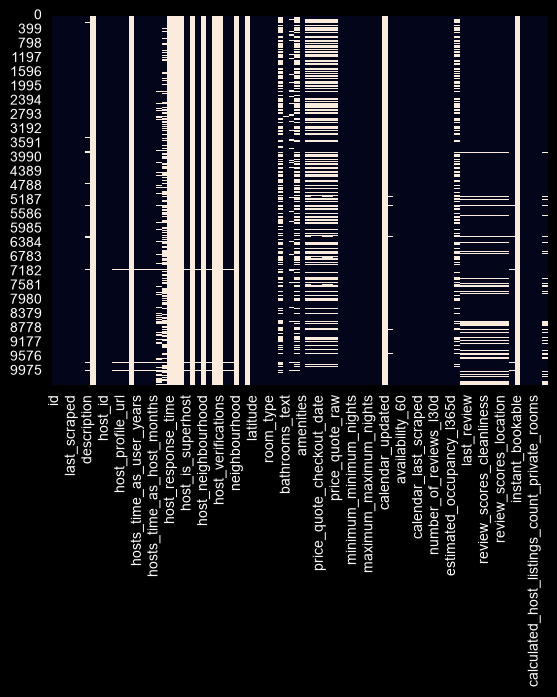

In [17]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [18]:
# Check Duplicate Rows

print(df.duplicated().sum())

0


In [19]:
# numerical columns

numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns)

Index(['id', 'scrape_id', 'neighborhood_overview', 'host_id',
       'host_profile_id', 'host_since', 'hosts_time_as_user_years',
       'hosts_time_as_user_months', 'hosts_time_as_host_years',
       'hosts_time_as_host_months', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'neighbourhood', 'neighbourhood_group_cleansed',
       'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms',
       'beds', 'price_quote_total_price', 'price_quote_price_per_night',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar_updated', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_revie